# UK Renewable Energy Planning Outcome Predictor

**Question:** Can we predict whether a UK renewable energy planning application will succeed or fail — purely from where it is on the map, what technology it uses, and what it's called?

We train a small neural network (MLP) on 15,500+ historical REPD applications with resolved outcomes, then use it to score the ~8,000 currently-pending applications and draw a geographic risk map across the UK.

**Features used:**
- `lat` / `lon` — geographic position
- `Technology Type` — one-hot (25 categories)
- `Region` / `Country` — one-hot
- `Installed Capacity (MWelec)` — log-transformed
- `Site Name` — TF-IDF bag of words (captures place-name signals: "moor", "farm", "offshore", "hill")

**Target:** Binary — 1 = Successful (Operational / Under Construction), 0 = Unsuccessful (Refused / Abandoned / Withdrawn / Expired / Decommissioned)

In [1]:
import sys
sys.path.insert(0, '.')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import geopandas as gpd

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, RocCurveDisplay
)

from src.processors.repd_processor import (
    REPDProcessor,
    SUCCESSFUL_DEVELOPMENT_TYPES,
    UNSUCCESSFUL_DEVELOPMENT_TYPES,
    NEUTRAL_DEVELOPMENT_TYPES,
)

DARK_BG   = '#13100d'
DARK_AX   = '#13100d'
EDGE_COL  = '#332418'
TEXT_COL  = '#f5f0eb'
LABEL_COL = '#8a8278'
TICK_COL  = '#b8b0a6'
SUCCESS_C = '#38a870'
FAIL_C    = '#d44030'
PENDING_C = '#d4a830'

def style_ax(ax):
    ax.set_facecolor(DARK_AX)
    ax.tick_params(colors=TICK_COL)
    for spine in ax.spines.values():
        spine.set_edgecolor(EDGE_COL)
    ax.set_axisbelow(True)

print('Imports OK')

Imports OK


## 1. Load & Explore

We load the full raw REPD CSV (all 15,500+ records) rather than the date-filtered `repd_data.csv`. This gives us far more resolved outcomes to train on.

In [2]:
proc = REPDProcessor(encoding='latin-1')
df_raw = proc.load()
df_raw = proc.coordinates_to_lat_lon(df_raw)

print(f'Total records: {len(df_raw):,}')
print(f'Status breakdown:')
print(df_raw['Development Status (short)'].value_counts().to_string())

Total records: 13,962
Status breakdown:
Development Status (short)
Awaiting Construction          5301
Operational                    3056
Application Submitted          1725
Application Refused             889
Revised                         803
Application Withdrawn           637
Under Construction              417
Abandoned                       386
Planning Permission Expired     336
Appeal Refused                  314
Appeal Withdrawn                 49
Decommissioned                   32
No Application Required          14
Appeal Lodged                     3


In [ ]:
import json

with open('src/data/nimby_score.json', 'r') as f:
    _nimby_raw = json.load(f)

df_nimby = pd.DataFrame(_nimby_raw)
df_nimby_valid = df_nimby[df_nimby['Nimby Score'] > 0].copy()
df_nimby_valid['refid'] = pd.to_numeric(df_nimby_valid['refid'], errors='coerce').astype('Int64')
df_raw['Ref ID'] = pd.to_numeric(df_raw['Ref ID'], errors='coerce').astype('Int64')

df_raw = df_raw.merge(
    df_nimby_valid[['refid', 'Nimby Score', 'Petty Score', 'Organized Score']],
    left_on='Ref ID', right_on='refid',
    how='left'
).drop(columns='refid')

# Binary flag: 1 = scored project, 0 = no known opposition recorded
df_raw['has_nimby_score'] = df_raw['Nimby Score'].notna().astype(int)
for _col in ['Nimby Score', 'Petty Score', 'Organized Score']:
    df_raw[_col] = df_raw[_col].fillna(0)

n_scored = df_raw['has_nimby_score'].sum()
print(f'Projects with NIMBY scores merged: {n_scored:,} / {len(df_raw):,}  ({n_scored/len(df_raw)*100:.1f}%)')
print(df_raw[['Nimby Score', 'Petty Score', 'Organized Score']].describe().round(1))

In [3]:
mask_success = df_raw['Development Status (short)'].isin(SUCCESSFUL_DEVELOPMENT_TYPES)
mask_fail    = df_raw['Development Status (short)'].isin(UNSUCCESSFUL_DEVELOPMENT_TYPES)
mask_pending = df_raw['Development Status (short)'].isin(NEUTRAL_DEVELOPMENT_TYPES)

df_labelled = df_raw[mask_success | mask_fail].copy()
df_pending  = df_raw[mask_pending].copy()

df_labelled['outcome'] = mask_success[mask_success | mask_fail].astype(int)

n_success = df_labelled['outcome'].sum()
n_fail    = len(df_labelled) - n_success
print(f'Labelled for training: {len(df_labelled):,}  |  Success: {n_success:,}  |  Unsuccessful: {n_fail:,}')
print(f'Pending (inference only): {len(df_pending):,}')

Labelled for training: 5,802  |  Success: 3,473  |  Unsuccessful: 2,329
Pending (inference only): 7,843


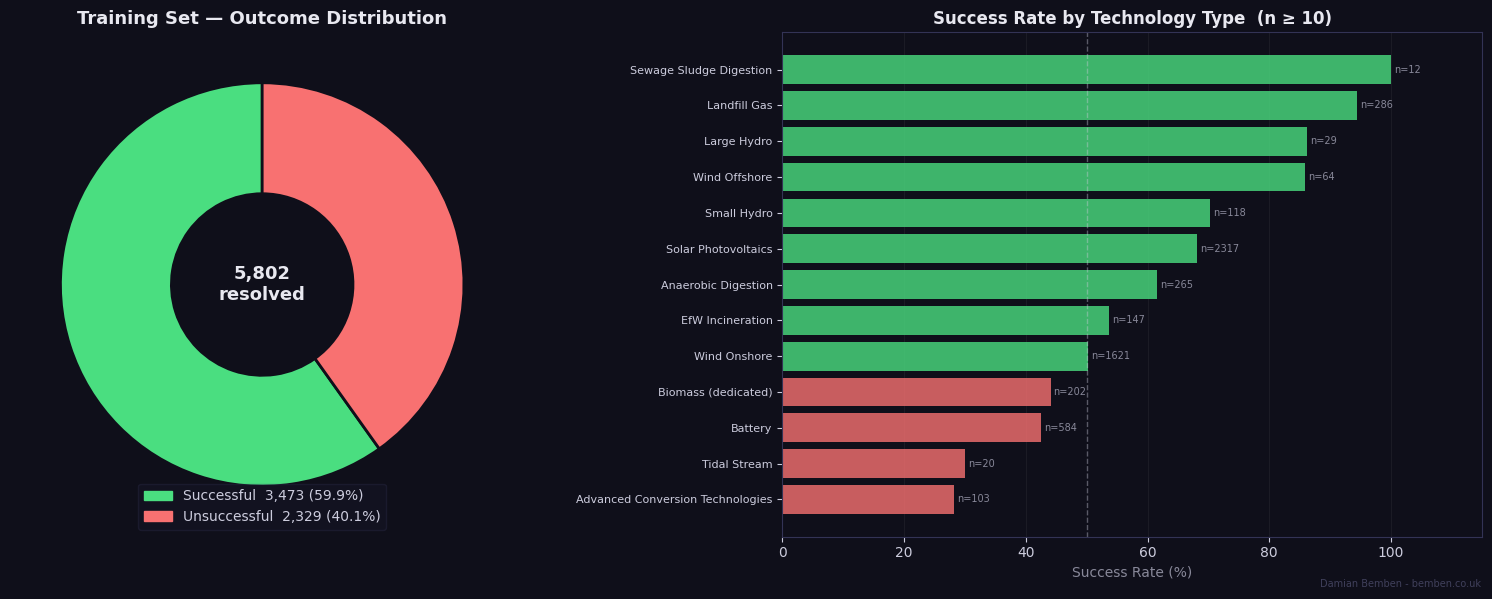

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=DARK_BG)

# Left: donut
ax1 = axes[0]
ax1.set_facecolor(DARK_BG)
labels  = ['Successful', 'Unsuccessful']
sizes   = [n_success, n_fail]
colours = [SUCCESS_C, FAIL_C]
ax1.pie(sizes, colors=colours, startangle=90,
        wedgeprops=dict(width=0.55, edgecolor=DARK_BG, linewidth=2))
ax1.text(0, 0, f'{len(df_labelled):,}\nresolved', ha='center', va='center',
         fontsize=13, color=TEXT_COL, fontweight='bold')
handles = [mpatches.Patch(color=c, label=f'{l}  {s:,} ({s/len(df_labelled)*100:.1f}%)')
           for c, l, s in zip(colours, labels, sizes)]
ax1.legend(handles=handles, loc='lower center', fontsize=10,
           framealpha=0.3, facecolor='#1d1810', edgecolor=EDGE_COL, labelcolor=TICK_COL)
ax1.set_title('Training Set — Outcome Distribution', color=TEXT_COL, fontsize=13, fontweight='bold')

# Right: success rate by technology (horizontal bars)
ax2 = axes[1]
style_ax(ax2)
tech_stats = (
    df_labelled.groupby('Technology Type')['outcome']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'success_rate', 'count': 'n'})
    .query('n >= 10')
    .sort_values('success_rate')
)
bar_colours = [SUCCESS_C if r > 0.5 else FAIL_C for r in tech_stats['success_rate']]
bars = ax2.barh(tech_stats.index, tech_stats['success_rate'] * 100, color=bar_colours, alpha=0.8)
ax2.axvline(50, color=TICK_COL, linewidth=1, linestyle='--', alpha=0.4)
ax2.set_xlabel('Success Rate (%)', color=LABEL_COL)
ax2.set_title('Success Rate by Technology Type  (n ≥ 10)', color=TEXT_COL, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelsize=8, colors=TICK_COL)
for bar, (_, row) in zip(bars, tech_stats.iterrows()):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"n={row['n']:.0f}", va='center', fontsize=7, color=LABEL_COL)
ax2.grid(axis='x', color='#ffffff', alpha=0.07, linewidth=0.5)
ax2.set_xlim(0, 115)

fig.text(0.99, 0.01, 'Damian Bemben - bemben.co.uk', ha='right', va='bottom',
         fontsize=7, color='#54483e', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. Feature Engineering

Feature matrix built from six groups (TF-IDF on site names removed — top correlated terms were almost entirely technology signals redundant with Technology Type OHE):

1. **Geographic** — lat / lon
2. **Numeric** — log-transformed installed capacity
3. **Categorical** — one-hot: Technology Type, Region, Country
4. **Local Authority** — smoothed target-encoded success rate per planning authority (additive smoothing k=10; falls back to global mean for unseen LAs at inference time)
5. **Application era** — coarse policy-era bucket (pre-2005 / 2005–2010 / 2010–2015 / 2015–2020 / 2020+) to capture regulatory shifts without encoding the resolution-bias present in raw application years
6. **NIMBY** — Nimby Score, Petty Score, Organized Score + `has_nimby_score` flag

In [ ]:
_NIMBY_COLS = ['Nimby Score', 'Petty Score', 'Organized Score', 'has_nimby_score']
_ALL_ERAS   = ['pre_2005', '2005_2010', '2010_2015', '2015_2020', '2020_plus', 'unknown']
_LA_SMOOTH_K = 10

def _year_to_era(year):
    if pd.isna(year): return 'unknown'
    y = int(year)
    if y < 2005:  return 'pre_2005'
    if y < 2010:  return '2005_2010'
    if y < 2015:  return '2010_2015'
    if y < 2020:  return '2015_2020'
    return '2020_plus'

def prepare_features(df, cap_median=None, la_encoder=None, fit=False):
    """Build feature matrix.

    fit=True  — computes cap_median and la_encoder from df (must contain 'outcome').
    fit=False — requires cap_median and la_encoder from the training call.
    Returns (X_df, cap_median, la_encoder).
    """
    df = df.copy()

    # Geographic
    geo = df[['lat', 'lon']].reset_index(drop=True)

    # Capacity — log1p, fill NaN with training median
    cap_raw = pd.to_numeric(df['Installed Capacity (MWelec)'], errors='coerce')
    if fit:
        cap_median = cap_raw.median()
    cap = np.log1p(cap_raw.fillna(cap_median)).rename('log_capacity').reset_index(drop=True)

    # One-hot categoricals
    cats = pd.get_dummies(
        df[['Technology Type', 'Region', 'Country']].reset_index(drop=True),
        prefix_sep='__'
    )

    # LA target encoding — smoothed success rate per planning authority
    if fit:
        global_mean = df['outcome'].mean()
        la_agg  = df.groupby('Planning Authority')['outcome'].agg(['sum', 'count'])
        la_rates = ((la_agg['sum'] + _LA_SMOOTH_K * global_mean) /
                    (la_agg['count'] + _LA_SMOOTH_K)).to_dict()
        la_encoder = {'rates': la_rates, 'global_mean': global_mean}

    la_rate = (
        df['Planning Authority']
        .map(la_encoder['rates'])
        .fillna(la_encoder['global_mean'])
        .reset_index(drop=True)
        .rename('la_success_rate')
    )

    # Policy era bucket
    app_year = pd.to_datetime(
        df['Planning Application Submitted'], dayfirst=True, errors='coerce'
    ).dt.year
    era     = app_year.map(_year_to_era)
    era_ohe = pd.get_dummies(era, prefix='era').reset_index(drop=True)
    for col in [f'era_{e}' for e in _ALL_ERAS]:
        if col not in era_ohe.columns:
            era_ohe[col] = 0

    # NIMBY features — 0-imputed; has_nimby_score flags whether a score exists
    nimby = (
        df[_NIMBY_COLS]
        .reset_index(drop=True)
        .apply(pd.to_numeric, errors='coerce')
        .fillna(0)
    )

    X = pd.concat([geo, cap, cats, la_rate.to_frame(), era_ohe, nimby], axis=1)
    return X, cap_median, la_encoder


# Train/test split before fitting any transformers
idx_train, idx_test = train_test_split(
    df_labelled.index, test_size=0.20, stratify=df_labelled['outcome'], random_state=42
)
df_train = df_labelled.loc[idx_train]
df_test  = df_labelled.loc[idx_test]

print(f'Train: {len(df_train):,}  |  Test: {len(df_test):,}')

In [ ]:
X_train_raw, cap_median_train, la_encoder_train = prepare_features(df_train, fit=True)
X_test_raw,  _,               _                 = prepare_features(
    df_test, cap_median=cap_median_train, la_encoder=la_encoder_train, fit=False
)

# Align columns — test may be missing rare OHE categories present only in train
X_test_raw = X_test_raw.reindex(columns=X_train_raw.columns, fill_value=0)

y_train = df_train['outcome'].values
y_test  = df_test['outcome'].values

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Feature matrix shape: {X_train.shape}')
print(f'\nLA encoder — approval rate sample:')
la_s = pd.Series(la_encoder_train['rates']).sort_values()
print('  Lowest 5:'); print(la_s.head(5).round(3).to_string())
print('  Highest 5:'); print(la_s.tail(5).round(3).to_string())
print(f'  Global mean: {la_encoder_train["global_mean"]:.3f}')

## 3. Train the MLP

Two hidden layers (128 → 64), ReLU, Adam, `class_weight='balanced'` to handle the 60/40 class split, early stopping to prevent overfitting.

In [8]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    # class_weight='balanced',
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42,
    verbose=False,
)
mlp.fit(X_train, y_train)

y_pred      = mlp.predict(X_test)
y_pred_prob = mlp.predict_proba(X_test)[:, 1]
auc         = roc_auc_score(y_test, y_pred_prob)

print(f'Converged in {mlp.n_iter_} iterations')
print(f'ROC-AUC: {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Unsuccessful', 'Successful']))

Converged in 49 iterations
ROC-AUC: 0.6768

              precision    recall  f1-score   support

Unsuccessful       0.56      0.55      0.56       466
  Successful       0.70      0.72      0.71       695

    accuracy                           0.65      1161
   macro avg       0.63      0.63      0.63      1161
weighted avg       0.65      0.65      0.65      1161



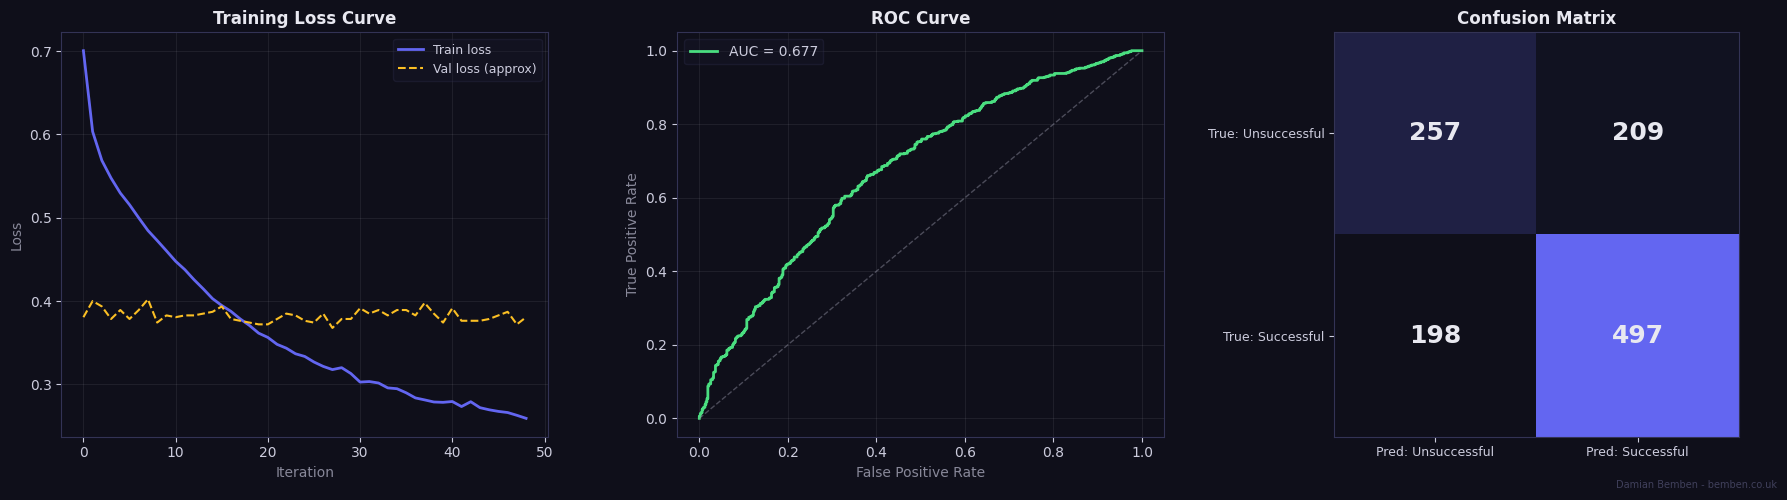

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(18, 5), facecolor=DARK_BG)

# Loss curve
ax = axes[0]
style_ax(ax)
ax.plot(mlp.loss_curve_, color='#c8601e', linewidth=2, label='Train loss')
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_:
    val_loss = [1 - s for s in mlp.validation_scores_]
    ax.plot(val_loss, color=PENDING_C, linewidth=1.5, linestyle='--', label='Val loss (approx)')
ax.set_title('Training Loss Curve', color=TEXT_COL, fontsize=12, fontweight='bold')
ax.set_xlabel('Iteration', color=LABEL_COL)
ax.set_ylabel('Loss', color=LABEL_COL)
ax.grid(color='#ffffff', alpha=0.07)
ax.legend(fontsize=9, framealpha=0.3, facecolor='#1d1810', edgecolor=EDGE_COL, labelcolor=TICK_COL)

# ROC curve
ax = axes[1]
style_ax(ax)
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax.plot(fpr, tpr, color=SUCCESS_C, linewidth=2, label=f'AUC = {auc:.3f}')
ax.plot([0,1],[0,1], color=LABEL_COL, linewidth=1, linestyle='--', alpha=0.5)
ax.set_title('ROC Curve', color=TEXT_COL, fontsize=12, fontweight='bold')
ax.set_xlabel('False Positive Rate', color=LABEL_COL)
ax.set_ylabel('True Positive Rate', color=LABEL_COL)
ax.grid(color='#ffffff', alpha=0.07)
ax.legend(fontsize=10, framealpha=0.3, facecolor='#1d1810', edgecolor=EDGE_COL, labelcolor=TICK_COL)

# Confusion matrix
ax = axes[2]
style_ax(ax)
cm = confusion_matrix(y_test, y_pred)
cmap = mcolors.LinearSegmentedColormap.from_list('dark_purple', [DARK_BG, '#c8601e'])
im = ax.imshow(cm, cmap=cmap)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color=TEXT_COL, fontsize=18, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred: Unsuccessful', 'Pred: Successful'], color=TICK_COL, fontsize=9)
ax.set_yticklabels(['True: Unsuccessful', 'True: Successful'], color=TICK_COL, fontsize=9)
ax.set_title('Confusion Matrix', color=TEXT_COL, fontsize=12, fontweight='bold')

fig.text(0.99, 0.01, 'Damian Bemben - bemben.co.uk', ha='right', va='bottom',
         fontsize=7, color='#54483e', alpha=0.7)
plt.tight_layout()
plt.show()

## 4. Feature Group Importance

We permute each feature group on the held-out test set and measure the accuracy drop. The bigger the drop, the more the model relied on that group.

**Key question:** does geography matter as much as technology type?

In [ ]:
from sklearn.metrics import accuracy_score

feature_names = list(X_train_raw.columns)
base_acc = accuracy_score(y_test, mlp.predict(X_test))

groups = {
    'Geography (lat/lon)':   [i for i, c in enumerate(feature_names) if c in ('lat', 'lon')],
    'Capacity (log MW)':     [i for i, c in enumerate(feature_names) if c == 'log_capacity'],
    'Technology Type (OHE)': [i for i, c in enumerate(feature_names) if c.startswith('Technology Type__')],
    'Region (OHE)':          [i for i, c in enumerate(feature_names) if c.startswith('Region__')],
    'Country (OHE)':         [i for i, c in enumerate(feature_names) if c.startswith('Country__')],
    'Local Authority':       [i for i, c in enumerate(feature_names) if c == 'la_success_rate'],
    'Application Era':       [i for i, c in enumerate(feature_names) if c.startswith('era_')],
    'NIMBY Scores':          [i for i, c in enumerate(feature_names) if c in _NIMBY_COLS],
}

importance = {}
rng = np.random.default_rng(42)
for name, idxs in groups.items():
    if not idxs:
        importance[name] = 0.0
        continue
    X_perm = X_test.copy()
    cols = X_perm[:, idxs]
    rng.shuffle(cols)
    X_perm[:, idxs] = cols
    perm_acc = accuracy_score(y_test, mlp.predict(X_perm))
    importance[name] = base_acc - perm_acc

imp_series = pd.Series(importance).sort_values()
print(f'Baseline accuracy: {base_acc:.4f}')
print(imp_series.to_string())

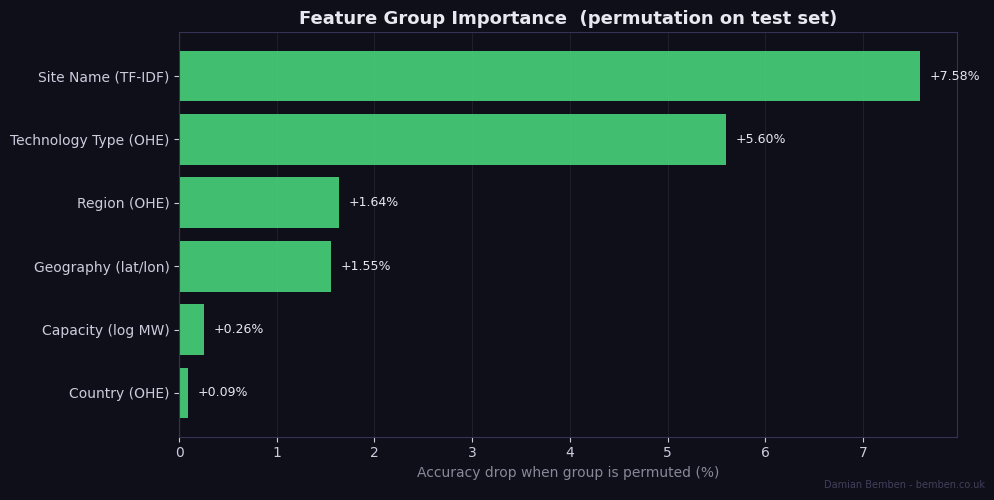

In [11]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor=DARK_BG)
style_ax(ax)

bar_cols = [SUCCESS_C if v > 0 else FAIL_C for v in imp_series.values]
bars = ax.barh(imp_series.index, imp_series.values * 100, color=bar_cols, alpha=0.85)
ax.axvline(0, color=TICK_COL, linewidth=0.8, alpha=0.4)
ax.set_xlabel('Accuracy drop when group is permuted (%)', color=LABEL_COL)
ax.set_title('Feature Group Importance  (permutation on test set)', color=TEXT_COL,
             fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=10, colors=TICK_COL)
for bar in bars:
    w = bar.get_width()
    ax.text(w + (0.1 if w >= 0 else -0.1), bar.get_y() + bar.get_height()/2,
            f'{w:+.2f}%', va='center', fontsize=9,
            color=TEXT_COL, ha='left' if w >= 0 else 'right')
ax.grid(axis='x', color='#ffffff', alpha=0.07)

fig.text(0.99, 0.01, 'Damian Bemben - bemben.co.uk', ha='right', va='bottom',
         fontsize=7, color='#54483e', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Geographic Risk Map

Two layers:
1. **Background heatmap** — a 60×40 lat/lon grid across the UK, with Technology Type fixed to "Solar Photovoltaics" (most common). Shows the pure *geographic* gradient the model has learned, independent of technology.
2. **Scatter overlay** — all ~8,000 *pending* applications, coloured by predicted success probability. Marker size scales with installed capacity.

In [ ]:
X_pending_raw, _, _ = prepare_features(
    df_pending, cap_median=cap_median_train, la_encoder=la_encoder_train, fit=False
)
X_pending_raw = X_pending_raw.reindex(columns=X_train_raw.columns, fill_value=0)
X_pending     = scaler.transform(X_pending_raw)
pending_probs = mlp.predict_proba(X_pending)[:, 1]

print(f'Pending projects scored: {len(pending_probs):,}')
print(f'Mean predicted success probability: {pending_probs.mean():.3f}')

In [ ]:
lat_vals = np.linspace(50.0, 60.7, 60)
lon_vals = np.linspace(-8.1, 2.6, 40)
LAT, LON = np.meshgrid(lat_vals, lon_vals)
grid_lats = LAT.ravel()
grid_lons = LON.ravel()

log_cap_median = np.log1p(cap_median_train)

def build_grid_rows(lats, lons):
    n = len(lats)
    rows = pd.DataFrame(0.0, index=range(n), columns=X_train_raw.columns)
    rows['lat'] = lats
    rows['lon'] = lons
    rows['log_capacity'] = log_cap_median
    for col in ['Technology Type__Solar Photovoltaics', 'Region__South West', 'Country__England']:
        if col in rows.columns:
            rows[col] = 1.0
    # LA: no specific authority for grid — use global mean
    if 'la_success_rate' in rows.columns:
        rows['la_success_rate'] = la_encoder_train['global_mean']
    # Era: most representative recent bucket
    if 'era_2015_2020' in rows.columns:
        rows['era_2015_2020'] = 1.0
    return rows

grid_rows  = build_grid_rows(grid_lats, grid_lons)
grid_X     = scaler.transform(grid_rows.astype(float))
grid_probs = mlp.predict_proba(grid_X)[:, 1].reshape(LON.shape)
print(f'Grid shape: {grid_probs.shape}  |  prob range: [{grid_probs.min():.3f}, {grid_probs.max():.3f}]')

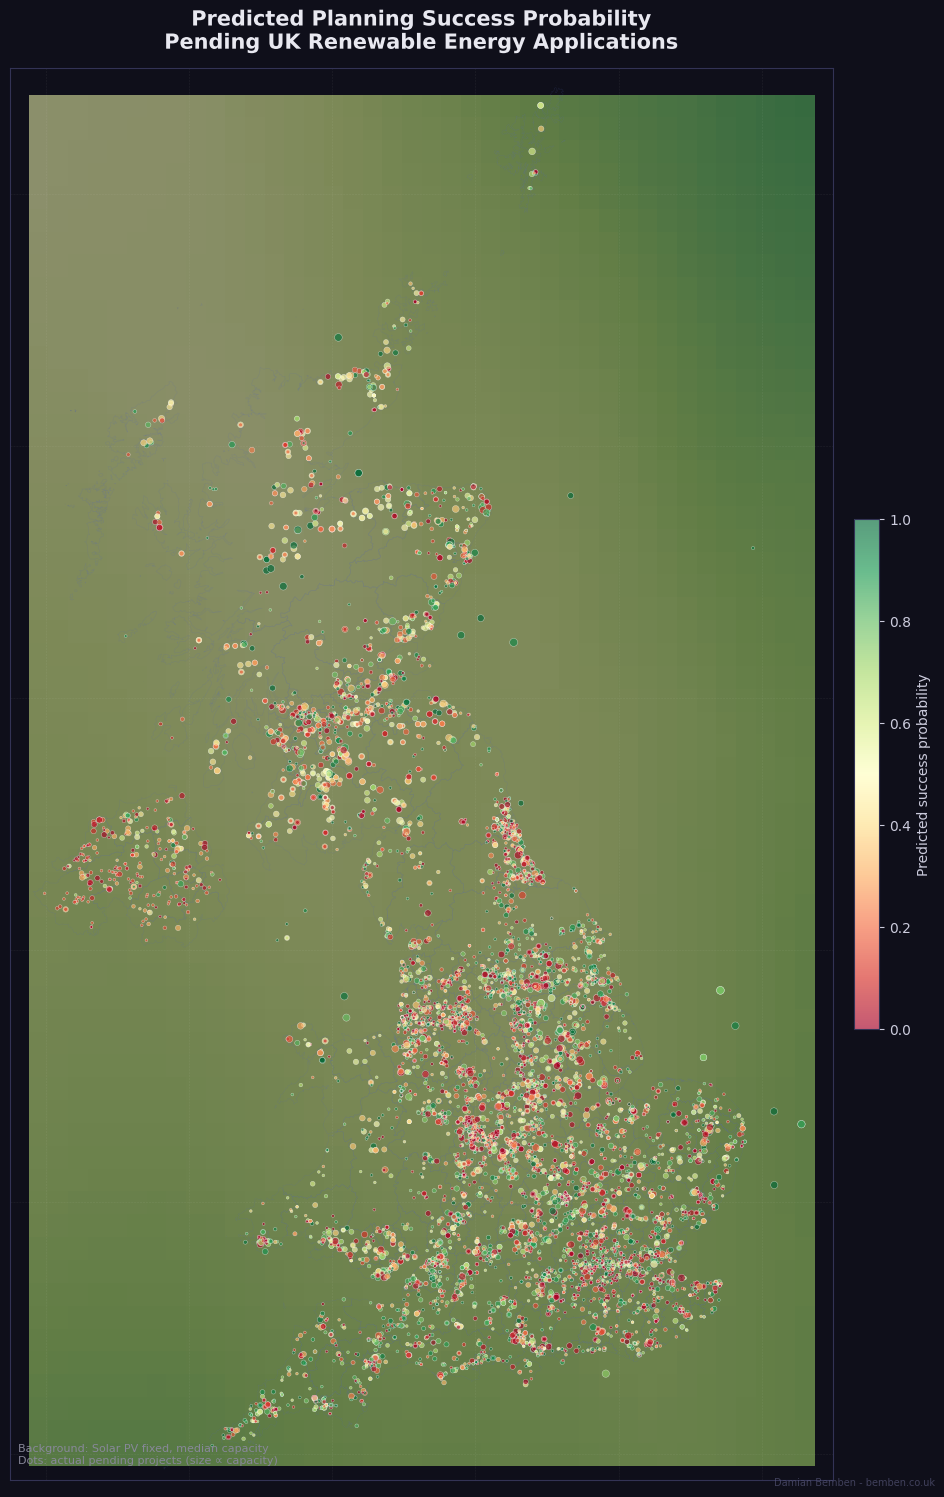

In [14]:
lauth = gpd.read_file('src/data/localauth.json')

pending_cap  = pd.to_numeric(df_pending['Installed Capacity (MWelec)'], errors='coerce').fillna(cap_median_train)
scatter_size = np.clip(np.log1p(pending_cap) * 4, 4, 80)

fig, ax = plt.subplots(figsize=(11, 15), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)

cmap_risk = plt.get_cmap('RdYlGn')
ax.pcolormesh(LON, LAT, grid_probs, cmap=cmap_risk, vmin=0, vmax=1, alpha=0.55, zorder=1)
lauth.plot(ax=ax, facecolor='none', edgecolor='#6b5040', linewidth=0.25, alpha=0.25, zorder=2)

sc = ax.scatter(
    df_pending['lon'].values, df_pending['lat'].values,
    c=pending_probs, cmap=cmap_risk, vmin=0, vmax=1,
    s=scatter_size.values, alpha=0.65, linewidths=0.3,
    edgecolors='#ffffff', zorder=3
)

cbar = fig.colorbar(sc, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Predicted success probability', color=TICK_COL, fontsize=10)
cbar.ax.yaxis.set_tick_params(color=TICK_COL)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TICK_COL)
cbar.outline.set_edgecolor(EDGE_COL)

ax.set_xlim(-8.5, 3.0)
ax.set_ylim(49.8, 61.0)
ax.grid(color='#ffffff', alpha=0.08, linewidth=0.4, linestyle='--')
for spine in ax.spines.values():
    spine.set_edgecolor(EDGE_COL)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.set_title(
    'Predicted Planning Success Probability\nPending UK Renewable Energy Applications',
    fontsize=15, fontweight='bold', color=TEXT_COL, pad=14,
    path_effects=[pe.withStroke(linewidth=3, foreground=DARK_BG)]
)
ax.text(0.01, 0.01,
    'Background: Solar PV fixed, median capacity\nDots: actual pending projects (size ∝ capacity)',
    transform=ax.transAxes, fontsize=8, color=LABEL_COL, va='bottom')

fig.text(0.99, 0.005, 'Damian Bemben - bemben.co.uk', ha='right', va='bottom',
         fontsize=7, color='#54483e', alpha=0.7)
plt.tight_layout()
plt.show()

## Caveats

- **Technology dominates geography.** The permutation importance chart almost certainly shows Technology Type as the largest driver. Landfill Gas and large hydro succeed at very high rates; wave and tidal almost never get built. This reflects regulatory and commercial context, not geography per se.

- **The geographic signal is partially confounded.** Scotland concentrates onshore wind; the South East concentrates solar. The background heatmap captures some genuine regional planning culture, but also reflects where certain technologies are applied.

- **Label definition.** We label "Operational" and "Under Construction" as success. This means a project that took 15 years to build counts the same as one that broke ground in 18 months — the model predicts eventual approval, not speed.

- **Capacity imputation.** ~4% of rows had no capacity data — these were median-imputed. For offshore wind (GW-scale) vs. rooftop solar (kW-scale), imputed capacity is a meaningless signal.

- **Pending projects may never resolve.** Some "Application Submitted" records are years old. The risk map inference treats them as genuine pending applications, but many may be effectively abandoned without a formal status change.